In [2]:
import scanpy as sc
import scrublet as scr #要先install python-annoy ->install scrublet (Python == 3.10.18)
import numpy as np
import pandas as pd
import scipy.io as sio

In [4]:
# matrix.mtx
cell_gene_matrix= sio.mmread("../scRNA_DATA/mtx_nmosd/NMOSD_matrix.mtx").tocsr().T  
# R 輸出是 genes × cells
# Scanpy/AnnData 需要 cells × genes
#.tocsr() 轉成稀疏矩陣

scrub = scr.Scrublet(cell_gene_matrix)
doublet_scores, predicted_doublets = scrub.scrub_doublets()

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.63
Detected doublet rate = 0.1%
Estimated detectable doublet fraction = 50.4%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 0.2%
Elapsed time: 1142.8 seconds


In [5]:
# Gene name (設為column)
var_names = pd.read_csv("../scRNA_DATA/mtx_nmosd/NMOSD_features.tsv", header=None)[0].values

# Cell name (設為row)
obs_names = pd.read_csv("../scRNA_DATA//mtx_nmosd/NMOSD_barcodes.tsv", header=None)[0].values

# 建立 AnnData
adata = sc.AnnData(cell_gene_matrix)
adata.var_names = var_names
adata.obs_names = obs_names

In [ ]:
# 把 Scrublet 結果加進去
adata.obs['doublet_scores'] = doublet_scores
adata.obs['predicted_doublets'] = predicted_doublets

# 檢查前幾個細胞
print(adata.obs[['doublet_scores', 'predicted_doublets']].head())

                           doublet_scores  predicted_doublets
nmo008_ACACTGACAATGAAAC-1        0.091142               False
nmo008_AAGCCGCGTCGAAAGC-1        0.064278               False
nmo008_TCAGATGGTCAACTGT-1        0.069249               False
nmo008_CTAACTTGTTAAAGTG-1        0.052934               False
nmo008_AGAGCTTAGAGTAAGG-1        0.053850               False


(<Figure size 800x300 with 2 Axes>,
 array([<Axes: title={'center': 'Observed transcriptomes'}, xlabel='Doublet score', ylabel='Prob. density'>,
        <Axes: title={'center': 'Simulated doublets'}, xlabel='Doublet score', ylabel='Prob. density'>],
       dtype=object))

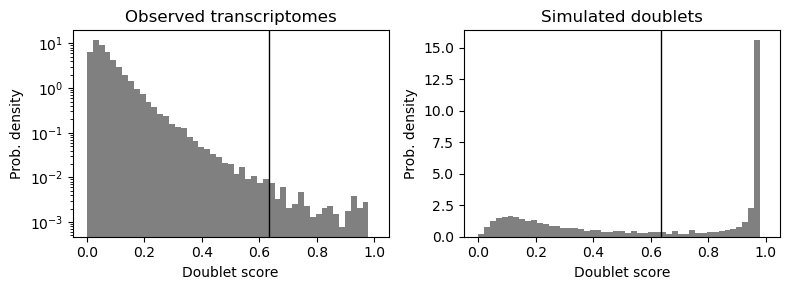

In [8]:
#視覺化與輸出結果
%matplotlib inline
scrub.plot_histogram()

In [10]:
#降維作圖視覺化結果
print('Running UMAP...')
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, n_neighbors=15, min_dist=0.3)) #預設

print('Done.')

Running UMAP...


c:\Users\JANE\.conda\envs\scrublet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Done.


(<Figure size 800x400 with 3 Axes>,
 array([<Axes: title={'center': 'Predicted doublets'}, xlabel='UMAP 1', ylabel='UMAP 2'>,
        <Axes: title={'center': 'Doublet score'}, xlabel='UMAP 1', ylabel='UMAP 2'>],
       dtype=object))

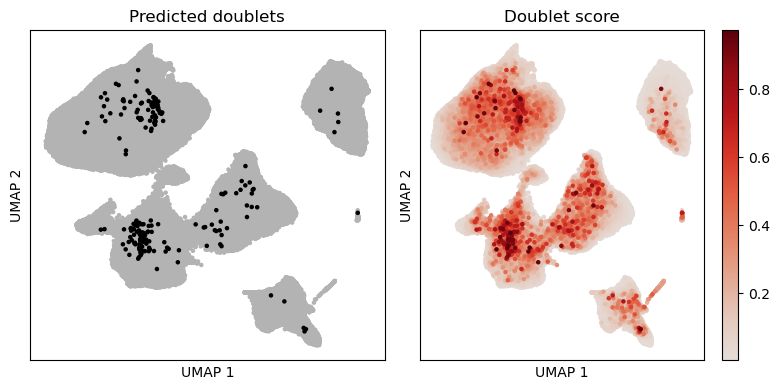

In [11]:
# 繪圖
scrub.plot_embedding('UMAP', order_points=True)